In [152]:
import yfinance as yf 
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from scipy.stats import norm,t

In [392]:
def extract_data(underlyings_list,valuation_date,look_back_period):
    # Default looking back period: 2 years 
    # end_date  =  (datetime.strptime(valuation_date, "%Y-%m-%d") + timedelta(days=1)).strftime("%Y-%m-%d")
    # The portfolio is all in US market. therefore timedelta can be set as days = 0
    end_date  =  (datetime.strptime(valuation_date, "%Y-%m-%d") + timedelta(days=0)).strftime("%Y-%m-%d")
    # end_date  =  (datetime.strptime(valuation_date, "%Y-%m-%d")).strftime("%Y-%m-%d")
    start_date = (datetime.strptime(end_date, "%Y-%m-%d") - timedelta(days=365*look_back_period)).strftime("%Y-%m-%d")
    extract_list = []
    for values in underlyings_list:
        data = yf.download(values, start=start_date, end=end_date, interval="1d")
        # data = yf.download(values, period = '2y', interval ='1d')
        data = data['Close'][[values]].reset_index()
        data.columns = ['Date',str(values) + "_close"]
        extract_list.append(data)
        # print(data) 
    combined_df = extract_list[0].copy()
    for df in extract_list[1:]:
        combined_df = pd.merge(combined_df, df, on='Date', how='inner')
    combined_df = combined_df.sort_values('Date').reset_index(drop=True)
    return combined_df

In [394]:
def get_mean_and_covariance_matrix(extract_df):
    extract_df = extract_df.copy()
    drift_rate_list = []
    for und in underlyings_list:
        extract_df[ und +"_daily_return"]=  (extract_df[und + "_close"]/extract_df[und + "_close"].shift(1)) - 1
    extract_df = extract_df.dropna()

    for und in underlyings_list:
        drift_rate_list.append( extract_df[ und +"_daily_return"].mean())
    drift_rate_df = pd.DataFrame(drift_rate_list, columns=['mean_daily_return'])
    
    daily_return_df = extract_df.filter(like='_daily_return')
    cov_df = daily_return_df.cov()
    return drift_rate_list, cov_df

In [396]:
def cholesky_decomposition(cov_df):
    # Cov = L.L^(T) , where L is lower triangular matrix.
    L=np.linalg.cholesky(cov_df)
    return L

In [398]:
def monte_carlo_simulation_gbm(extract_df, mtm_portfolio_value, portfolio_weighting, n_underlyings, n_simulation, n_step):
    drift_rate_list, cov_df = get_mean_and_covariance_matrix(extract_df)
    drift_array = np.array(drift_rate_list)
    drift_rate_matrix = np.zeros((n_simulation, n_step, n_underlyings)) + drift_array
    
    L = cholesky_decomposition(cov_df)
    U = np.random.random((n_simulation, n_step, n_underlyings))
    Z_normal = norm.ppf(U)
    # Z_t = t.ppf(U, df=3)    fitting t-distribution for monte carlo which can help on capturing more tail risk

    shock_gaussian = Z_normal@L.T
    simulated_daily_returns_underlying_level  = drift_rate_matrix + shock_gaussian

    simulated_cumulative_returns_underlying_level= np.cumsum(simulated_daily_returns_underlying_level, axis=1) + np.full((n_simulation, n_step, n_underlyings),fill_value = 1)
    simulated_cumulative_returns_portfolio_level = simulated_cumulative_returns_underlying_level.dot(portfolio_weighting)
    simulated_cumulative_mtm_portfolio_level = simulated_cumulative_returns_portfolio_level*mtm_portfolio_value
    columns_name = [f'step_{i}' for i in range(0, n_step + 1)]
    df_simulated_cumulative_mtm_portfolio_level = pd.DataFrame(simulated_cumulative_mtm_portfolio_level, columns=columns_name[1:])
    df_simulated_cumulative_mtm_portfolio_level[columns_name[0]] = mtm_portfolio_value
    df_simulated_cumulative_mtm_portfolio_level = df_simulated_cumulative_mtm_portfolio_level[[columns_name[0]] + columns_name[1:]]
    
    return cov_df, L, df_simulated_cumulative_mtm_portfolio_level

In [400]:
def get_MC_VaR(df_simulated_cumulative_mtm_portfolio_level,confident_interval):
    columns_name = df_simulated_cumulative_mtm_portfolio_level.columns
    df_simulated_PnL = pd.DataFrame()
    df_simulated_PnL['PnL'] = df_simulated_cumulative_mtm_portfolio_level[columns_name[0]] - df_simulated_cumulative_mtm_portfolio_level[columns_name[-1]]
    df_simulated_PnL = df_simulated_PnL.sort_values('PnL', ascending=True).reset_index(drop=True)
    MC_VaR = df_simulated_PnL['PnL'].quantile(1-confident_interval)
    return MC_VaR

In [402]:
def plot_monte_carlo_graph(df):
    plt.figure(figsize=(30, 6))
    for i in range(len(df)):
        plt.plot(
            df.columns,          # x-axis
            df.iloc[i],          # y-axis 
            linewidth=1.5,
            alpha=0.7,                                                    # transparency for many lines
            label=f'Simulation {i+1}' if i < 10 else None )

    # Customize the plot
    plt.title('Simulated MTM Portfolio Value Paths (Portfolio Level)', fontsize=14, fontweight='bold')
    plt.xlabel('Simulation Step')
    plt.ylabel('Portfolio Value')
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # legend outside if many lines
    plt.tight_layout()
    plt.show()

## Step 1: Portfolio Information Set-up

In [405]:
underlyings_list = ["COIN","NFLX","RACE"]
mtm_portfolio_value = 10000
portfolio_weighting = [0.3,0.3,0.4]

## Step 2: Extract Data Set-up

In [408]:
valuation_date = str(datetime.today().strftime("%Y-%m-%d"))
# valuation_date = "2025-12-31"
look_back_period = 1
extract_df = extract_data(underlyings_list,valuation_date,look_back_period)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Step 3 Monte Carlo Simulation Set-up

In [411]:
VaR_time_horizon = [10,30]
confident_interval = 0.95
n_simulation = 10000
n_underlyings = len(underlyings_list)

print(f"Running Date: {str(datetime.today())}")
print(f"Look back period: {len(extract_df)} Day from {extract_df['Date'][0]} to {extract_df['Date'].iloc[-1]} ")
print(f"Number of Simulation path is: {n_simulation }")
for time_horizon in VaR_time_horizon: 
    cov_df, L, df_simulated_cumulative_mtm_portfolio_level = monte_carlo_simulation_gbm(extract_df, mtm_portfolio_value, portfolio_weighting, n_underlyings, n_simulation, time_horizon)
    MC_VaR = get_MC_VaR(df_simulated_cumulative_mtm_portfolio_level,confident_interval)
    print(f"risk indictor - 95% MCVaR({time_horizon}D) is :{MC_VaR}")


Running Date: 2026-01-08 11:58:43.083435
Look back period: 250 Day from 2025-01-08 00:00:00 to 2026-01-07 00:00:00 
Number of Simulation path is: 10000
risk indictor - 95% MCVaR(10D) is :-1111.0331549476562
risk indictor - 95% MCVaR(30D) is :-1945.320489829095


## Step 4 Plot Monte Carlo Path on Portfolio Value

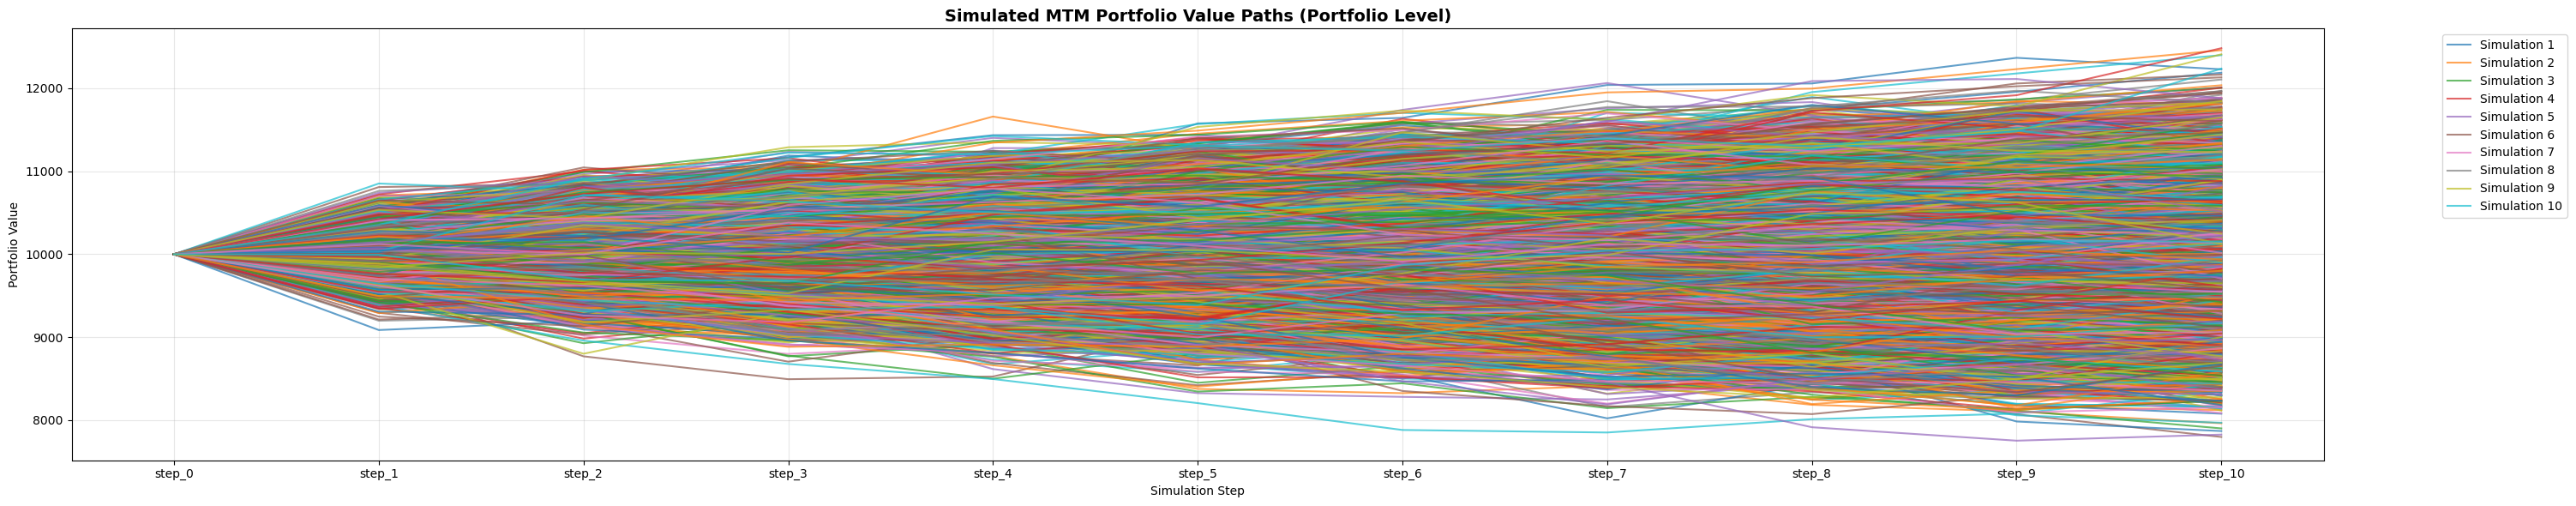

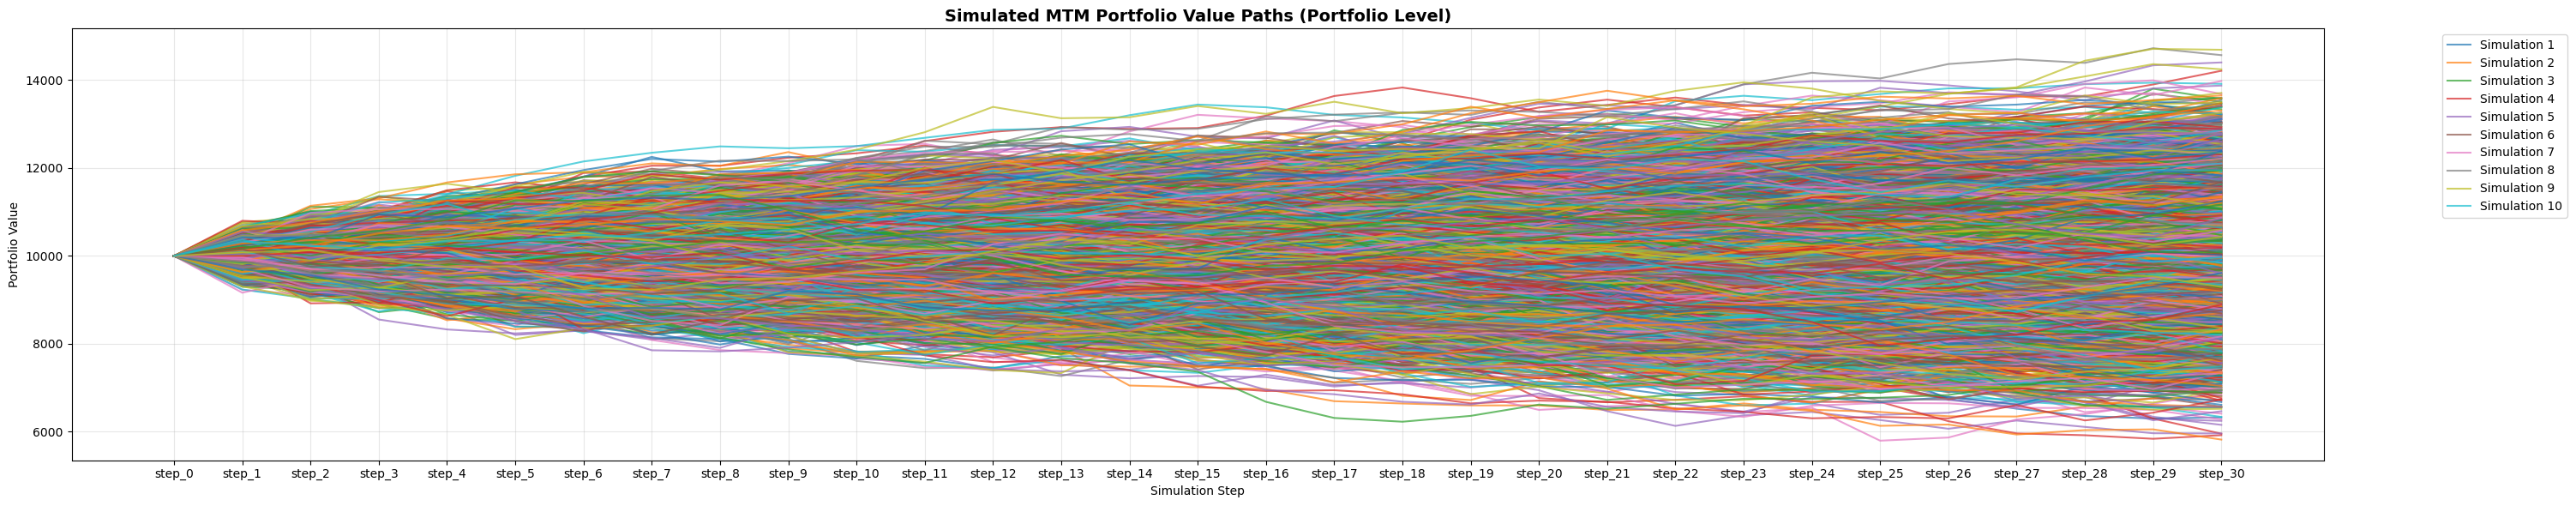

In [240]:
for time_horizon in VaR_time_horizon: 
    cov_df, L, df_simulated_cumulative_mtm_portfolio_level = monte_carlo_simulation_gbm(extract_df, mtm_portfolio_value, portfolio_weighting, n_underlyings, n_simulation, time_horizon)
    plot_monte_carlo_graph(df_simulated_cumulative_mtm_portfolio_level)